<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/0_diagnostico/diagnos_prueba_inicial_pivu/41.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

# Ejercicio 41 de la prueba final del PIVU

## Preguntas 41 y 42.

$A$, $B$ y $C$ son candidatos a la presidencia de una cooperativa.   

Una investigación mostró que, entre los socios entrevistados, 110 no van a votar.    

Entre los entrevistados que sí pretenden participar, 20 van a votar por el candidato $A$, 50 por el candidato $B$, 35 por el candidato $C$, 110 definitivamente no van a votar por el candidato $A$, 70 no van a votar por $C$, y 10 aun no han decidido entre $A$ y $C$.   

También, la investigación mostró que 15 de los entrevistados que pretenden votar, no tienen preferencia, y por tanto, pueden votar por cualquiera de los tres candidatos.   

Con base en estos datos:
41.	El número de entrevistados que no ha decidido si votar por B o por C es:

A.	0  
B.	15  
C.	25  
D.	30  

## Solución

Para resolver este problema de diagramas de Venn / teoría de conjuntos mediante programación en Python, utilizaremos **NumPy** y **Pandas** para formular y resolver el sistema de ecuaciones lineales correspondiente a las intersecciones de los votantes decididos, y **Matplotlib** para visualizar la distribución de los votantes.

---



### Análisis Matemático de los Datos

Definimos los conjuntos de votantes decididos entre los 3 candidatos ($A$, $B$ y $C$):

* Solo $A = a$
* Solo $B = b$
* Solo $C = c$
* Entre $A$ y $B$ (excluyendo $C$) = $x$
* Entre $B$ y $C$ (excluyendo $A$) = $y$
* Entre $A$ y $C$ (excluyendo $B$) = $z = 10$
* Entre $A$, $B$ y $C$ (indecisos entre los tres) = $i = 15$



De las premisas del enunciado extraemos las siguientes ecuaciones:

1. **Votantes seguros de A**: $a = 20$
2. **Votantes seguros de B**: $b = 50$
3. **Votantes seguros de C**: $c = 35$
4. **Definitivamente NO votan por A**: Son aquellos que están únicamente en los sectores de $B$, $C$, o la intersección $B \cap C$ (sin incluir ninguna parte de $A$).

$$\text{No } A \implies b + c + y = 110$$





Sustituyendo $b=50$ y $c=35$:

$$50 + 35 + y = 110 \implies 85 + y = 110 \implies y = 25$$


5. **Definitivamente NO votan por C**: Son aquellos que están únicamente en los sectores de $A$, $B$, o la intersección $A \cap B$ (sin incluir ninguna parte de $C$).

$$\text{No } C \implies a + b + x = 70$$



Sustituyendo $a=20$ y $b=50$:

$$20 + 50 + x = 70 \implies 70 + x = 70 \implies x = 0$$



Por lo tanto, el número de entrevistados indecisos únicamente entre **B y C** ($y$) es **25**.

**Respuesta Correcta:** **C. 25**

---



### Código en Python (NumPy, Pandas y Matplotlib)



--- RESUMEN DE VOTOS (PANDAS DATAFRAME) ---
  Categoría de Voto  Cantidad de Personas
             Solo A                    20
             Solo B                    50
             Solo C                    35
        Entre A y C                    10
        Entre A y B                     0
        Entre B y C                    25
Indecisos (A, B, C)                    15
           No Votan                   110

Resultado Pregunta 41 (Indecisos B o C): 25


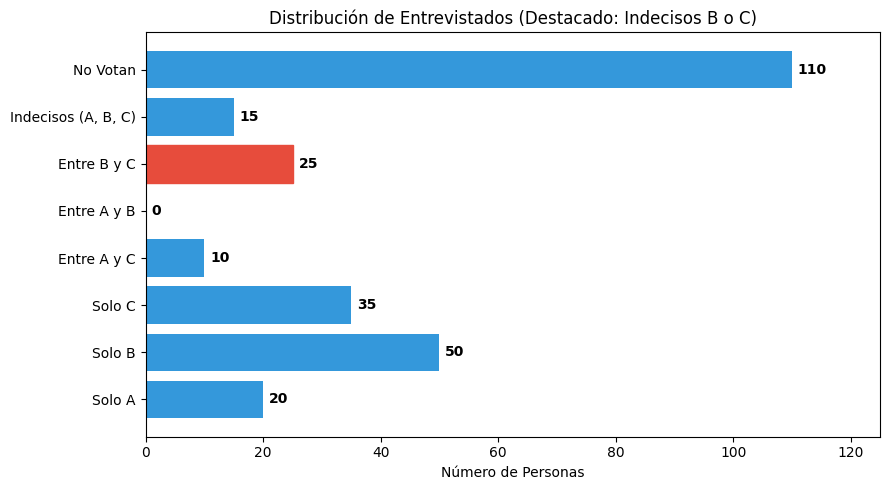

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Resolución del sistema con NumPy y Pandas
# ---------------------------------------------------------

# Planteamos las ecuaciones para resolver las variables desconocidas (x, y)
# Ecuación 1 (No A): b + c + y = 110  =>  y = 110 - b - c
# Ecuación 2 (No C): a + b + x = 70   =>  x = 70 - a - b

a, b, c = 20, 50, 35
z = 10  # Indecisos entre A y C
i = 15  # Indecisos entre los tres (A, B y C)

# Matriz de coeficientes para [x, y]
# Ecuación 1: 0*x + 1*y = 110 - 50 - 35 = 25
# Ecuación 2: 1*x + 0*y = 70 - 20 - 50 = 0
A_matrix = np.array([[0, 1], [1, 0]])

B_vector = np.array([110 - (b + c), 70 - (a + b)])

# Resolver el sistema lineal
solucion = np.linalg.solve(A_matrix, B_vector)
x_val, y_val = int(solucion[0]), int(solucion[1])

# Crear DataFrame con Pandas para resumir la distribución de votantes
datos = {
    'Categoría de Voto': [
        'Solo A',
        'Solo B',
        'Solo C',
        'Entre A y C',
        'Entre A y B',
        'Entre B y C',
        'Indecisos (A, B, C)',
        'No Votan',
    ],
    'Cantidad de Personas': [a, b, c, z, x_val, y_val, i, 110],
}

df_votantes = pd.DataFrame(datos)
print("--- RESUMEN DE VOTOS (PANDAS DATAFRAME) ---")
print(df_votantes.to_string(index=False))
print(f"\nResultado Pregunta 41 (Indecisos B o C): {y_val}")

# ---------------------------------------------------------
# 2. Visualización de Resultados con Matplotlib
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

# Graficar gráfico de barras de la distribución
bars = ax.barh(
    df_votantes['Categoría de Voto'],
    df_votantes['Cantidad de Personas'],
    color='#3498db',
)

# Destacar la respuesta a la pregunta 41
bars[5].set_color('#e74c3c')

# Etiquetas en las barras
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        ha='left',
        va='center',
        fontweight='bold',
    )

ax.set_title(
    'Distribución de Entrevistados (Destacado: Indecisos B o C)', fontsize=12
)
ax.set_xlabel('Número de Personas')
ax.set_xlim(0, 125)
plt.tight_layout()
plt.show()


## Tipo de razonamiento al que este ejercicio pertenece